Aqui está o texto traduzido para Português (Brasil), mantendo a formatação original que você enviou:

# **<span style="color:#682F2F;"><center>DIMENSÕES ROTULADAS DE UM DIAMANTE</center></span>**

<div style="border-radius:10px;
border : #682F2F solid;
background-color:#FFF8DC;
font-size:110%;
text-align: left">

## <h2 style='border:0; color:#682F2F'><center>Sobre os dados (Descrição dos atributos)</center></h2>

**Este dataset clássico contém os preços e outros atributos de quase 54.000 diamantes. Existem 10 atributos incluídos no conjunto de dados, incluindo o alvo (target), ou seja, o preço.**

* **carat (0.2-5.01):** O *carat* (quilate) é o peso físico do diamante medido em quilates métricos. Um quilate equivale a 0,20 gramas e é subdividido em 100 pontos.
* **cut (Fair, Good, Very Good, Premium, Ideal):** A qualidade do corte (lapidação). Quanto mais preciso for o corte do diamante, mais cativante ele é aos olhos, sendo assim de grau mais elevado.
* **color (de J (pior) a D (melhor)):** A cor dos diamantes com qualidade de gema ocorre em muitos matizes. Varia de incolor a amarelo claro ou marrom claro. Diamantes incolores são os mais raros. Outras cores naturais (azul, vermelho, rosa, por exemplo) são conhecidas como "fancy" (fantasia), e sua graduação de cor é diferente da dos diamantes brancos incolores.
* **clarity (I1 (pior), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (melhor)):** A pureza/clareza. Diamantes podem ter características internas conhecidas como inclusões ou características externas conhecidas como manchas. Diamantes sem inclusões ou manchas são raros; no entanto, a maioria das características só pode ser vista com ampliação.
* **depth (43-79)**: É a porcentagem de profundidade total que equivale a z / média(x, y) = 2 * z / (x + y). A profundidade do diamante é sua altura (em milímetros) medida do cúlase (*culet* - ponta inferior) até a mesa (superfície plana superior), conforme indicado no diagrama rotulado acima.
* **table (43-95):** É a largura do topo do diamante (mesa) em relação ao ponto mais largo. Ela confere ao diamante um fogo e brilho deslumbrantes ao refletir a luz em todas as direções, o que, quando visto por um observador, parece lustroso.
* **price ($$326 - $18826):** É o preço do diamante em dólares americanos. **É a nossa coluna alvo (target) no dataset.**
* **x (0 - 10.74):** Comprimento do diamante (em mm)
* **y (0 - 58.9):** Largura do diamante (em mm)
* **z (0 - 31.8):** Profundidade do diamante (em mm)

<a id = "title-one"><a>
<h1 style='background:#682F2F; border:0; border-radius: 10px; color:white'><center>IMPORTING LIBRARIES<center><h1>

In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement xgboost (from versions: none)
ERROR: No matching distribution found for xgboost


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn. linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
# from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import metrics 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

<a id = "title-two"></a>
<h1 style='background:#682F2F; border:0; border-radius: 10px; color:white'><center>LOADING DATA</center></h1>

In [6]:
data_df = pd.read_csv("C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/IA para Ciência de Dados/diamonds.csv")
data_df.sample(10)  

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
43867,43868,0.50,Ideal,H,VS1,60.5,57.0,1449,5.15,5.19,3.13
683,684,0.80,Very Good,F,SI1,63.4,57.0,2851,5.89,5.82,3.71
5811,5812,0.91,Premium,E,SI1,61.5,60.0,3911,6.19,6.24,3.82
5869,5870,0.92,Fair,H,VS1,56.0,60.0,3924,6.53,6.51,3.65
5919,5920,0.94,Very Good,F,SI2,62.6,57.0,3938,6.25,6.27,3.92
47906,47907,0.53,Ideal,G,VVS2,62.5,54.0,1914,5.21,5.19,3.25
40359,40360,0.43,Ideal,D,VS2,60.7,57.0,1129,4.91,4.88,2.97
45447,45448,0.52,Good,E,VS2,58.3,61.0,1673,5.26,5.31,3.08
24569,24570,1.01,Ideal,E,IF,61.4,57.0,12865,6.53,6.46,3.99
46014,46015,0.53,Premium,G,VS1,63.0,58.0,1727,5.17,5.15,3.25


<a id = "title-three"></a>
<h1 style='background: #682F2F; border:0; border-radius: 10px; color:white'><center>DATA ANALYSIS</center></h1>

### **<span style="color:#682F2F;"><center>Checking for missing values & categorical variables</center></span>**

In [7]:
# Checking for missing values and categorical variables in the dataset
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB




### **<span style="color:#682F2F;">Nota: </span>**

##### Existem 53.940 valores não nulos em todos os atributos, portanto, não há valores ausentes.

##### O tipo de dado das features 'cut', 'color' e 'clarity' é "object", o que precisa ser convertido em variável numérica (será feito no pré-processamento de dados) antes de alimentarmos os dados aos algoritmos.



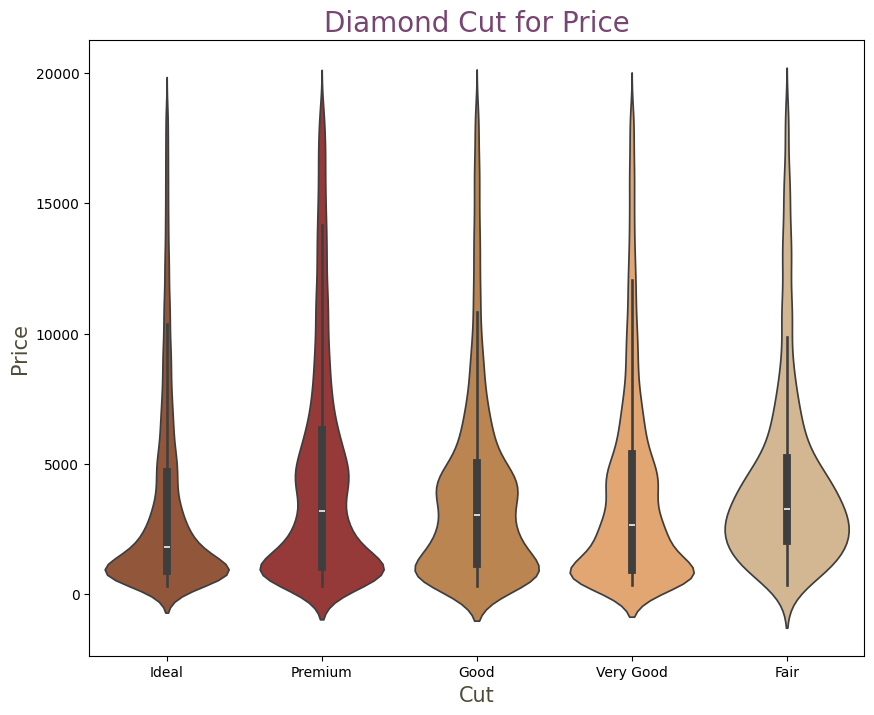

In [8]:
plt.figure(figsize=(10,8))
cols = ["#A0522D","#A52A2A","#CD853F","#F4A460","#DEB887"]
ax = sns.violinplot(x="cut",y="price", data=data_df, palette=cols,scale= "count")
ax.set_title("Diamond Cut for Price", color="#774571", fontsize = 20)
ax.set_ylabel("Price", color="#4e4c39", fontsize = 15)
ax.set_xlabel("Cut", color="#4e4c39", fontsize = 15)
plt.show()

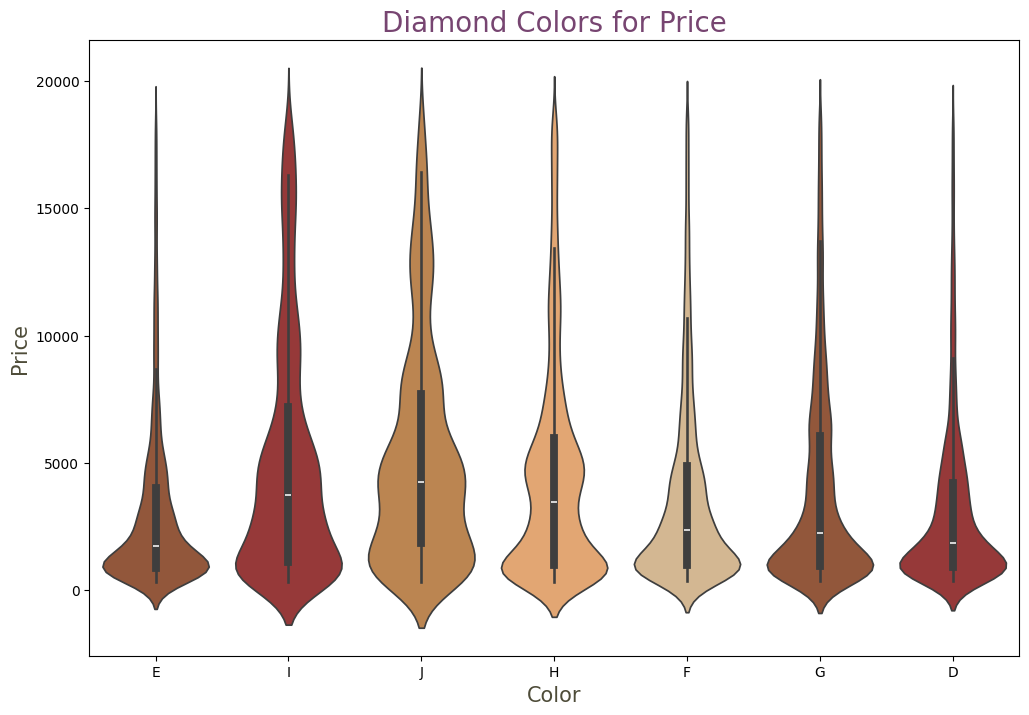

In [9]:
plt.figure(figsize=(12,8))
ax = sns.violinplot(x="color",y="price", data=data_df, palette=cols,scale= "count")
ax.set_title("Diamond Colors for Price", color="#774571", fontsize = 20)
ax.set_ylabel("Price", color="#4e4c39", fontsize = 15)
ax.set_xlabel("Color", color="#4e4c39", fontsize = 15)
plt.show()

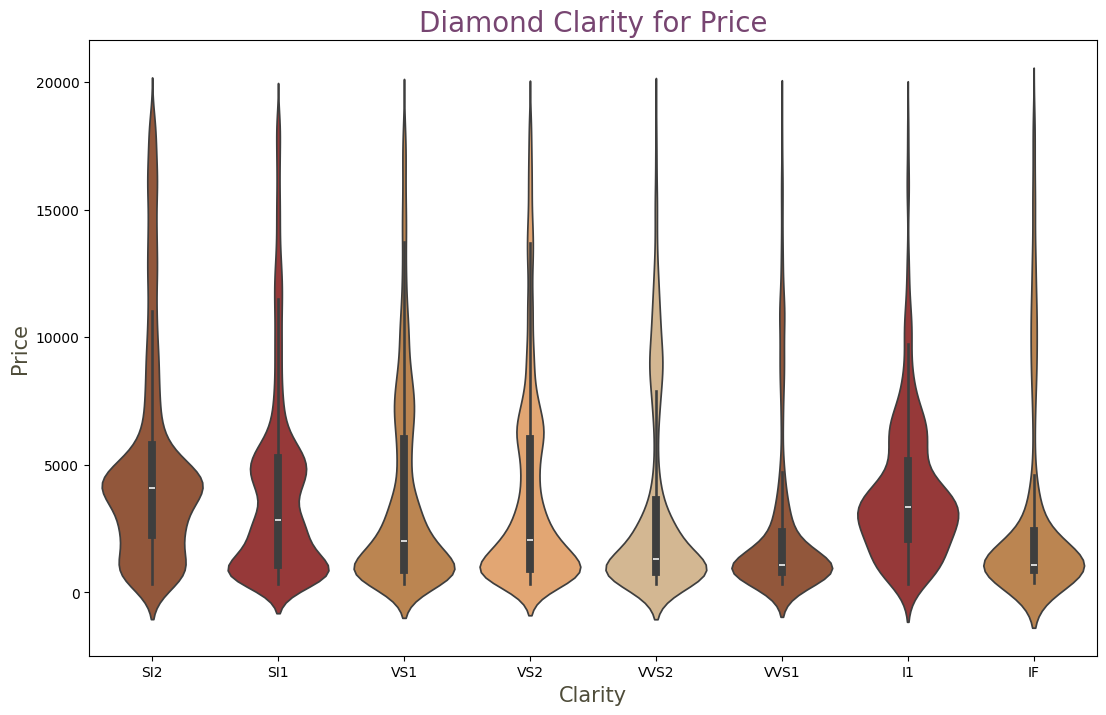

In [10]:
plt.figure(figsize=(13,8))
ax = sns.violinplot(x="clarity",y="price", data=data_df, palette=cols,scale= "count")
ax.set_title("Diamond Clarity for Price", color="#774571", fontsize = 20)
ax.set_ylabel("Price", color="#4e4c39", fontsize = 15)
ax.set_xlabel("Clarity", color="#4e4c39", fontsize = 15)
plt.show()


### **<span style="color:#682F2F;">Nota: </span>**

##### Cortes de diamante "Ideal" são a maioria em quantidade, enquanto "Fair" (Aceitável) são a minoria. Há mais diamantes de todos esses cortes na categoria de preço mais baixo.

##### Diamantes de cor "J", que é a pior, são os mais raros; no entanto, "H" e "G" existem em maior número, embora também sejam de qualidade inferior.

##### Diamantes de pureza "IF", que é a melhor, bem como "I1", que é a pior, são muito raros, e o restante é, em sua maioria, de purezas intermediárias.



### **<span style="color:#682F2F;"><center>Descriptive Statistics</center></span>**

In [11]:
# Doing Univariate Analysis for statistical description and understanding of dispersion of data
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,53940.0,26970.500000,15571.281097,1.0,13485.75,26970.50,40455.25,53940.00
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80
